# Part 1: Hierarchical Clustering - The Intuition & The Dendrogram

### 1. The Intuition: The 'Bottom-Up' Family Tree
Imagine a room full of people who don't know each other. In **Agglomerative (Bottom-Up) Clustering**, we follow a simple story:
1. **Isolation:** Initially, every single person is their own separate 'cluster'.
2. **The Handshake:** We find the two people who are most similar (closest together) and group them into a pair.
3. **The Ripple Effect:** We repeat this. We look for the next two closest individuals (or groups) and merge them.
4. **The Big Family:** This continues until everyone in the room belongs to one giant single cluster.

**Why is this awesome?**
Unlike K-Means, where we have to guess the number of clusters ($K$) before we even start, Hierarchical Clustering builds a map of relationships first. We can decide how many clusters we want *after* seeing how the data naturally connects!

### 2. Loading the Dataset
We are using the `Mall_Customers.csv` dataset. To keep things simple for our 2D visualization, we will only look at **Annual Income** and **Spending Score**.

**Why drop the others?**
- `CustomerID`: Just a random ID, it has no mathematical meaning.
- `Gender`: Categorical data that requires encoding.
- `Age`: While useful, using only two variables allows us to plot the data on a standard 2D graph (X and Y axes) to easily see the clusters with our own eyes.

In [ ]:
import pandas as pd # Import pandas for data manipulation

# Load the dataset from the local path
dataset = pd.read_csv('/content/Mall_Customers.csv')

# Extract columns at index 3 (Annual Income) and 4 (Spending Score)
# We use .values to convert the dataframe slice into a NumPy array for the ML model
X = dataset.iloc[:, [3, 4]].values

# Display the first 5 rows of our feature matrix X
print("First 5 rows of our features (Income and Spending Score):")
print(X[:5])

First 5 rows of our features (Income and Spending Score):
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


### 3. Drawing the Dendrogram (The Superpower)
A **Dendrogram** is like a memory log of every merge that happened. The vertical lines represent the distance (dissimilarity) between clusters. The taller the vertical line, the more 'different' the clusters being joined are.

**The Rule for Choosing 'K':**
Find the longest vertical line that you can cut through with a horizontal line *without* crossing any other horizontal 'branches'. The number of vertical lines your horizontal cut passes through is your optimal number of clusters!

### How the 5 Clusters are Calculated

1. **Distance Metric (Euclidean):** The algorithm calculates the straight-line distance between every pair of points.
2. **Linkage Method (Ward):** Instead of just looking at the closest points, the **Ward method** looks at the 'Analysis of Variance'. It tries to merge clusters in a way that the total within-cluster variance increases the least. This results in clusters that are more spherical and equal in size.
3. **The Stopping Point:** By drawing our line at a distance of 200, we told the algorithm to treat any branch crossing that line as a final, independent group.

Let's re-plot the dendrogram with colored branches to see these 5 groups distinctly!

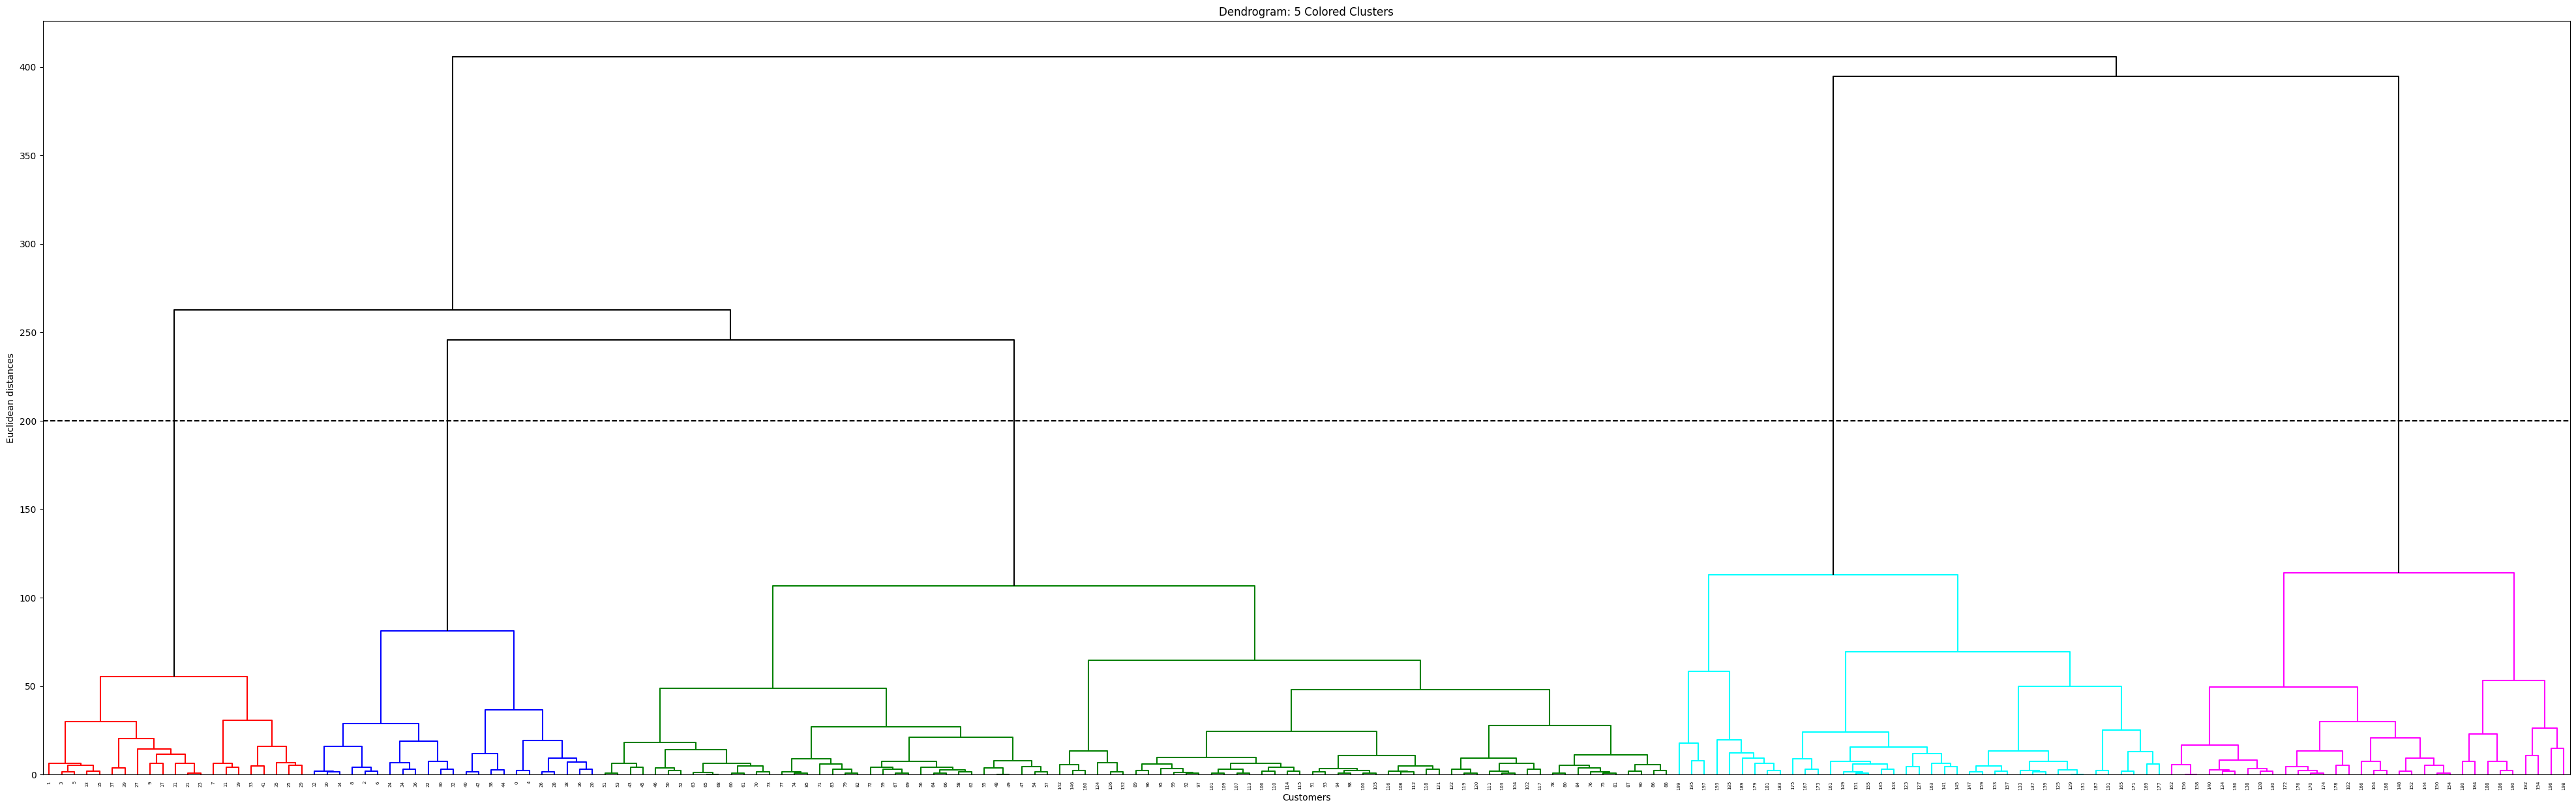

Each distinct color represent one of the 5 clusters formed by the cut!


In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Set the threshold to color the 5 clusters differently
# Since our cut was at 200, we set color_threshold=200
plt.figure(figsize=(50, 15))
sch.set_link_color_palette(['red', 'blue', 'green', 'cyan', 'magenta'])

# linkage with ward method
Z = sch.linkage(X, method='ward')

# Create the dendrogram with colored clusters
dendrogram = sch.dendrogram(Z, color_threshold=200, above_threshold_color='black')

plt.axhline(y=200, color='black', linestyle='--', label='Cut Line (K=5)')
plt.title('Dendrogram: 5 Colored Clusters')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

print("Each distinct color represent one of the 5 clusters formed by the cut!")

**Observation:** If you look at the resulting dendrogram, the largest vertical gap without horizontal intersections occurs in the middle-left area. If we draw a horizontal line through that gap, it intersects **5 vertical lines**. This tells us that for this specific mall data, **5 clusters** is the most natural fit!

# Part 2: Training the Hierarchical Clustering Model

### 1. Initializing the Model
Now that our Dendrogram has 'told' us that 5 is the optimal number of clusters, we can build our machine learning model using the `AgglomerativeClustering` class from scikit-learn.

**Key Parameters Explained:**
*   **`n_clusters=5`**: This is the number of groups we want the algorithm to create.
*   **`metric='euclidean'`**: This tells the model how to measure the distance between points. Think of it like using a **straight-line ruler** to measure the gap between two dots on a graph.
*   **`linkage='ward'`**: This is the strategy used to merge clusters. 'Ward' is the most popular because it tries to keep the clusters tight and compact by **minimizing the variance** (the 'spread') inside each cluster.

In [ ]:
from sklearn.cluster import AgglomerativeClustering # Import the clustering class

# Initialize our model with the settings we decided on
# n_clusters=5: We want 5 groups
# metric='euclidean': Measure distance using straight lines
# linkage='ward': Use the Ward method to minimize variance within clusters
hc = AgglomerativeClustering(n_clusters = 5, metric = 'euclidean', linkage = 'ward')

# The model is now ready, but it hasn't seen our data yet!

### 2. Fitting and Predicting
This is the 'Heavy Lifting' phase. When we call `fit_predict`, the algorithm performs all those merges we saw in the Dendrogram intuition, but it stops exactly when it reaches 5 clusters.

It then assigns a 'Label' (a number from 0 to 4) to every single customer in our dataset, indicating which group they belong to.

In [ ]:
# We use fit_predict to both train the model and get the cluster assignments in one go
# We store the resulting cluster numbers in a variable called 'y_hc'
y_hc = hc.fit_predict(X)

# Print the cluster assignments for the first 20 customers
print("Cluster assignments for the first 20 customers (0, 1, 2, 3, or 4):")
print(y_hc[:20])

Cluster assignments for the first 20 customers (0, 1, 2, 3, or 4):
[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3]


# Part 3: Visualizing the Clusters & The Verdict

### 1. Plotting the Final Clusters
Now we bring our data to life! We will use a scatter plot where each point is a customer. By coloring them based on the `y_hc` labels we just created, we can clearly see the five distinct segments of mall shoppers.

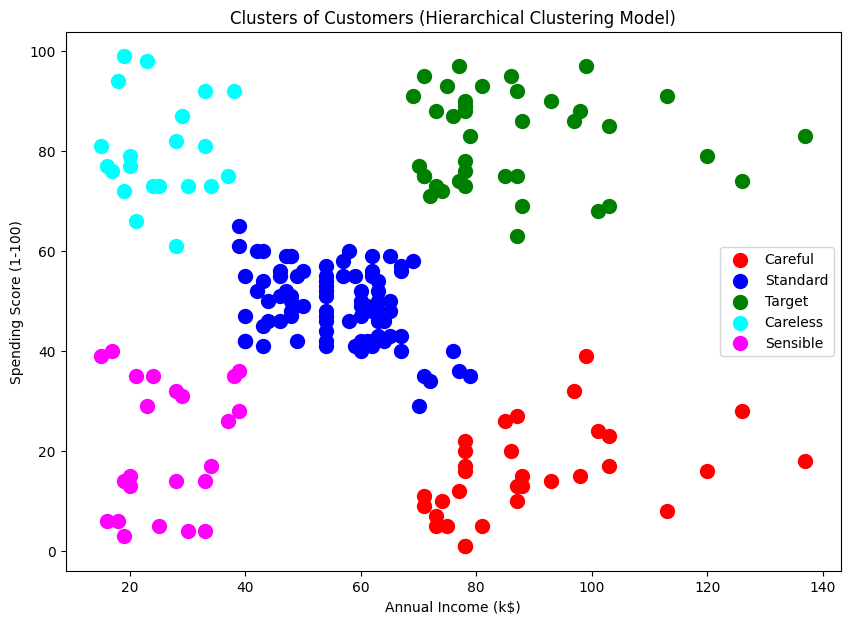

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Create a large figure for better visibility
plt.figure(figsize=(10, 7))

# Plot Cluster 1: High Income, Low Spend (Careful)
# X[y_hc == 0, 0] selects 'Annual Income' for all rows assigned to cluster 0
# X[y_hc == 0, 1] selects 'Spending Score' for all rows assigned to cluster 0
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label = 'Careful')

# Plot Cluster 2: Average Income, Average Spend (Standard)
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label = 'Standard')

# Plot Cluster 3: High Income, High Spend (Target)
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label = 'Target')

# Plot Cluster 4: Low Income, High Spend (Careless)
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'cyan', label = 'Careless')

# Plot Cluster 5: Low Income, Low Spend (Sensible)
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Sensible')

# Add the finishing touches to the graph
plt.title('Clusters of Customers (Hierarchical Clustering Model)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend() # Show the labels we created above
plt.show()

### 2. Hierarchical vs. K-Means (When to use which?)

Now that you've mastered both, here is how to choose your weapon in the real world:

| Feature | Hierarchical Clustering | K-Means Clustering |
| :--- | :--- | :--- |
| **Number of Clusters** | No need to guess! The **Dendrogram** tells you the answer. | You must guess $K$ (or use the Elbow Method). |
| **Speed** | **Slow** on large datasets. It has to calculate distances between every single pair. | **Very Fast**. It is the go-to for massive datasets. |
| **Data Size** | Best for small to medium datasets (a few thousand rows). | Handles millions of rows with ease. |
| **Intuition** | Builds a hierarchy (tree) of relationships. | Groups data around central points (centroids). |

### **Conclusion**
Congratulations! You have successfully used **Hierarchical Clustering** to segment a real retail dataset into actionable business target groups. You can now identify who your 'Target' customers are (High Income, High Spend) versus those who are more 'Careful' with their money!